### Zbiór danych - Predict Students Dropout, Academic Success

Celem analizy jest określenie jakie warunki sprzyjają skończeniu studiów. 

W notesie przedstawiono szczegółową analizę czynników wpływających na przedwczesne kończenie nauki przez studentów. Badanie oparto na zbiorze danych zatytułowanym „Predict Students Dropout, Academic Success”, pochodzącym z platformy Kaggle, którego autorem jest użytkownik thedevastator. Zestaw ten zawiera szeroki zakres atrybutów, które pozwalają na identyfikację zjawisk determinujących rezygnację ze studiów lub osiągnięcie sukcesu akademickiego.

Zmienne można podzielić na cztery główne kategorie tematyczne:
1. Dane demograficzne i społeczno-ekonomiczne
•	Stan cywilny oraz pochodzenie: Zmienne określające stan cywilny (Marital status), narodowość (Nacionality) oraz status studenta zagranicznego (International).
•	Sytuacja rodzinna: Szczegółowe dane dotyczące wykształcenia oraz profilu zawodowego rodziców (Mother's/Father's qualification oraz Mother's/Father's occupation), pozwalające na ocenę wpływu kapitału kulturowego i ekonomicznego gospodarstwa domowego.
•	Czynniki migracyjne i adaptacyjne: Informacja o tym, czy student musiał zmienić miejsce zamieszkania w celu podjęcia nauki (Displaced).
2. Profil rekrutacyjny i kontekst instytucjonalny
•	Informacje o rekrutacji: Tryb aplikacji (Application mode), priorytet wybranego kierunku (Application order) oraz dotychczasowe formalne wykształcenie (Previous qualification).
•	Organizacja toku studiów: Wybrany kierunek (Course) oraz tryb odbywania zajęć – dzienny lub wieczorowy (Daytime/evening attendance).
•	Profil indywidualny: Wiek w momencie podejmowania studiów (Age at enrollment), płeć (Gender) oraz obecność specjalnych potrzeb edukacyjnych (Educational special needs).
3. Status finansowy studenta
•	Zobowiązania i wsparcie: Wskaźniki określające, czy student posiada zadłużenie wobec uczelni (Debtor), czy regularnie opłaca czesne (Tuition fees up to date) oraz czy przyznano mu wsparcie materialne w postaci stypendium (Scholarship holder).
4. Osiągnięcia akademickie (w rozbiciu na 1. i 2. semestr)
Dla każdego z dwóch pierwszych semestrów gromadzone są precyzyjne wskaźniki efektywności naukowej:
•	Liczba punktów/przedmiotów przepisywanych z innych kierunków (credited).
•	Liczba przedmiotów, na które student został zapisany (enrolled).
•	Liczba podejść do egzaminów i zaliczeń (evaluations).
•	Liczba faktycznie zaliczonych przedmiotów (approved).
•	Średnia uzyskanych ocen (grade).
•	Liczba przedmiotów porzuconych bez próby podejścia do weryfikacji wiedzy (without evaluations).
5. Wskaźniki makroekonomiczne
Kontekst zewnętrzny w momencie rejestracji danych uzupełniają trzy wskaźniki gospodarcze kraju: stopa bezrobocia (Unemployment rate), stopa inflacji (Inflation rate) oraz dynamika PKB (GDP).
Zmienna docelowa (Target)
Zmienna objaśniana Target jest zmienną kategoryczną o charakterze klasyfikacyjnym, przyjmującą trzy stany:
	1.	Dropout – student przedwcześnie przerwał naukę (skreślenie lub rezygnacja).
	2.	Enrolled – student kontynuuje naukę (pozostaje w systemie).
	3.	Graduate – student pomyślnie ukończył cykl kształcenia i uzyskał dyplom.

In [1]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn import svm


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import VotingClassifier


data = pd.read_csv("./dataset.csv")
data.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [3]:

data.isnull().sum()/len(data)*100



Marital status                                    0.0
Application mode                                  0.0
Application order                                 0.0
Course                                            0.0
Daytime/evening attendance                        0.0
Previous qualification                            0.0
Nacionality                                       0.0
Mother's qualification                            0.0
Father's qualification                            0.0
Mother's occupation                               0.0
Father's occupation                               0.0
Displaced                                         0.0
Educational special needs                         0.0
Debtor                                            0.0
Tuition fees up to date                           0.0
Gender                                            0.0
Scholarship holder                                0.0
Age at enrollment                                 0.0
International               

### W zbiorze danych nie ma pustych wartości

In [4]:
print(data["Target"].unique())

<StringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str


### Kolumna target przyjmuje wartości Dropout, Graduate, Enrolled, więc można je zamienić na 0, 1, 2.

In [5]:
data['Target'] = data['Target'].map({
    'Dropout':0,
    'Enrolled':1,
    'Graduate':2
})

print(data["Target"].unique())

[0 2 1]


### Usuwamy dane nie mające korelacji z target

In [6]:
data.corr()['Target']




Marital status                                   -0.089804
Application mode                                 -0.212025
Application order                                 0.089791
Course                                            0.007841
Daytime/evening attendance                        0.075107
Previous qualification                           -0.091365
Nacionality                                      -0.004740
Mother's qualification                           -0.038346
Father's qualification                            0.000329
Mother's occupation                               0.048424
Father's occupation                               0.051702
Displaced                                         0.113986
Educational special needs                        -0.007353
Debtor                                           -0.240999
Tuition fees up to date                           0.409827
Gender                                           -0.229270
Scholarship holder                                0.2975

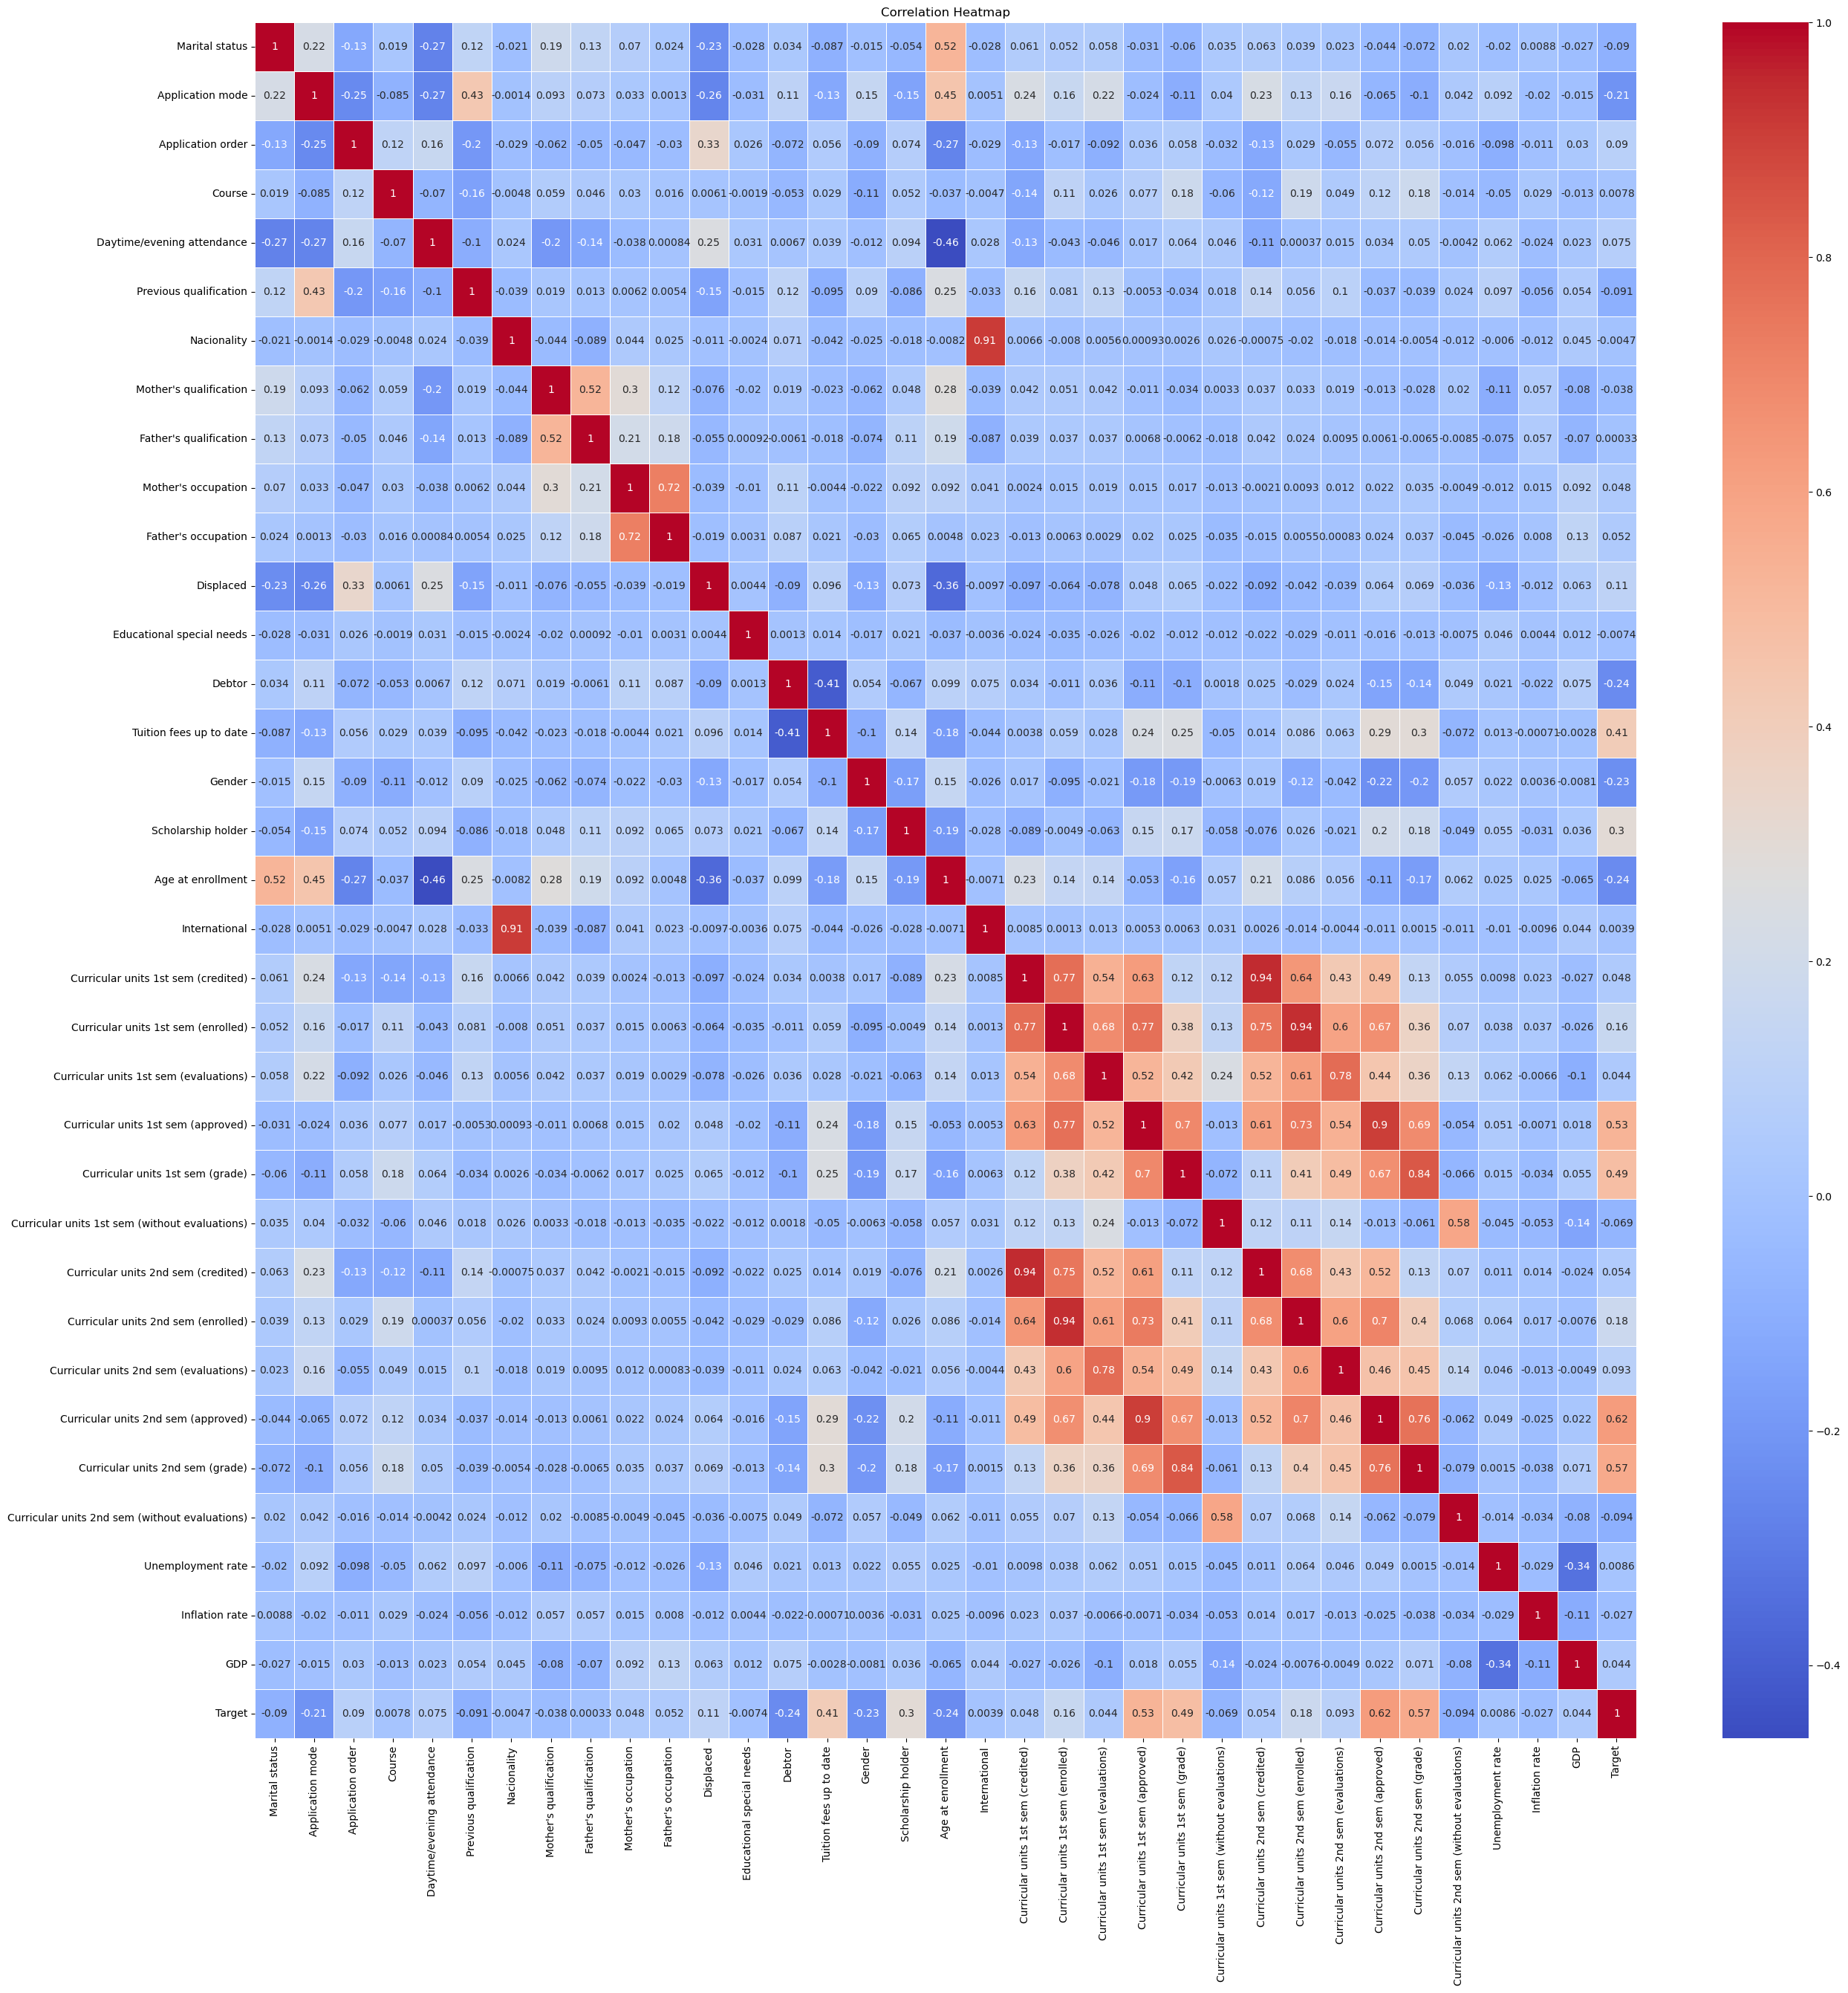

In [7]:
plt.figure(figsize=(30, 30))
sns.heatmap(data.corr() , annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



### Dla dokładności modelu możemy usunąć dane mające mniej niż 0.1 korelacji z kolumną target.

In [8]:
new_data = data.copy()
new_data = new_data.drop(columns=['Nacionality', 
                                  'Mother\'s qualification', 
                                  'Father\'s qualification', 
                                  'Educational special needs', 
                                  'International', 
                                  'Curricular units 1st sem (without evaluations)',
                                  'Unemployment rate', 
                                  'Inflation rate'])
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Mother's occupation                             4424 non-null   int64  
 7   Father's occupation                             4424 non-null   int64  
 8   Displaced                                       4424 non-null   int64  
 9   Debtor                                          4424

#EDA
Ilość wartości dropouts, enrolled i graduates

In [9]:


new_data['Target'].value_counts()



Target
2    2209
0    1421
1     794
Name: count, dtype: int64

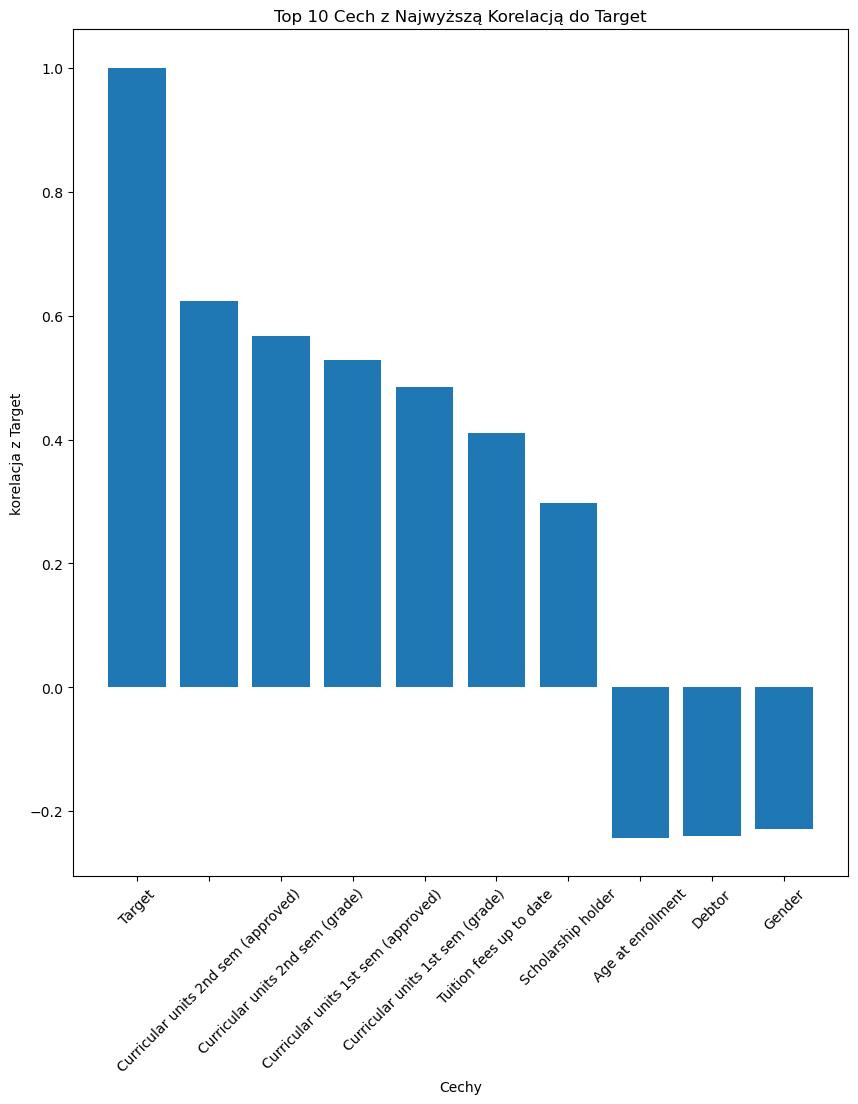

In [10]:

correlations = data.corr()['Target']
top_10_features = correlations.abs().nlargest(10).index
top_10_corr_values = correlations[top_10_features]

plt.figure(figsize=(10, 11))
plt.bar(top_10_features, top_10_corr_values)
plt.xlabel('Cechy')
plt.ylabel('korelacja z Target')
plt.title('Top 10 Cech z Najwyższą Korelacją do Target')
plt.xticks(rotation=45)
plt.show()



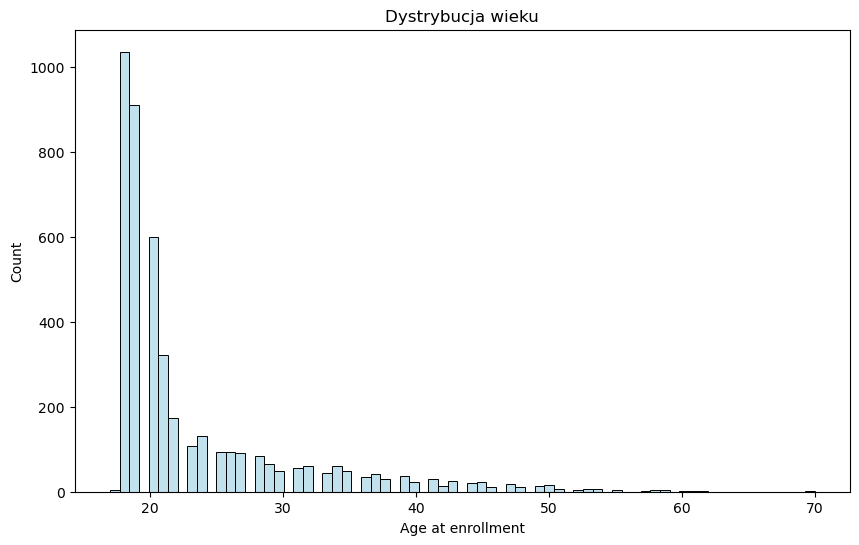

In [23]:

plt.figure(figsize=(10,6))
sns.histplot(new_data['Age at enrollment'], color='lightblue', kde=False)
plt.xlabel('Age at enrollment')
plt.title('Dystrybucja wieku')
plt.show()

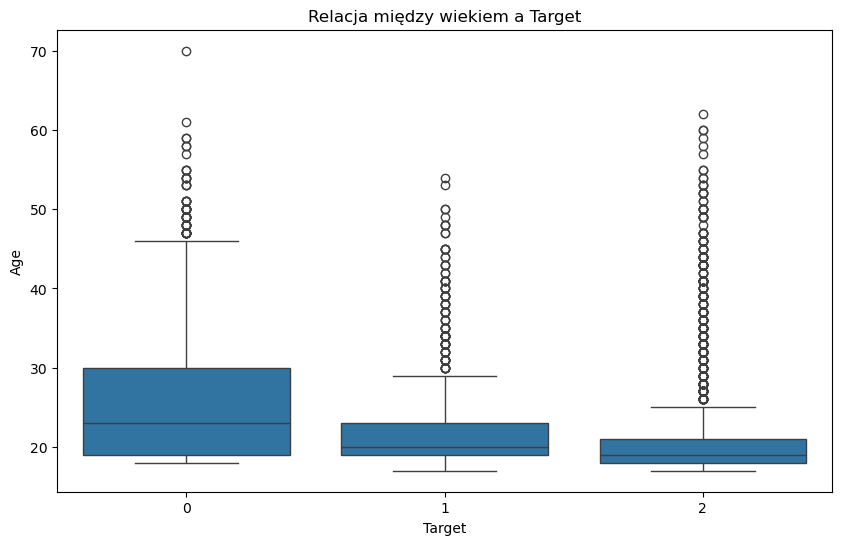

In [27]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='Age at enrollment', data=new_data)
plt.xlabel('Target')
plt.ylabel('Age')
plt.title('Relacja między wiekiem a Target')
plt.show()

In [ ]:
X = new_data.drop('Target', axis=1)
y = new_data['Target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=67)


## modele do analizy danych 


